### Instalação Pacotes caso não reconheça os instalados em requeriments

In [18]:
pip install geopandas matplotlib mapclassify factor-analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor-analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=e56e736905554475699abc6997815d15acc7591b3269eec347254d6413d25a59
  Stored in directory: /home/thaliaphotos/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor-analyzer
Note: you may need to restart the kernel to use updated packages.


### CONEXÃO COM A TABELA DO DBT

In [2]:
import duckdb
import pandas as pd
import os

DB_PATH = 'dbt_project/data/censo_escolar.duckdb'

if not os.path.exists(DB_PATH):
    print(f"❌ Arquivo não encontrado!")
else:
    con = duckdb.connect(DB_PATH, read_only=True)
    
    # Corrigido: Sem espaços entre as vírgulas
    con.execute("SET search_path='main_refined,main_staging,main'")
    
    # Agora o select vai funcionar direto
    df = con.execute("SELECT * FROM refined_censo_escolar").df()
    
    pd.set_option('display.max_columns', None)
    print(f"✅ Sucesso! {len(df)} linhas carregadas.")
    display(df.head())

✅ Sucesso! 180540 linhas carregadas.


,CO_ENTIDADE,NU_ANO_CENSO,SG_UF,NO_MUNICIPIO,CO_MUNICIPIO,NO_REGIAO,dependencia_adm,localizacao,possui_internet,internet_alunos,possui_banda_larga,possui_computador,acesso_internet_computador,internet_aprendizagem,internet_comunidade,laboratorio_informatica,possui_desktop_aluno,possui_portatil_aluno,possui_tablet_aluno,IN_INTERNET,IN_INTERNET_ALUNOS,IN_EQUIP_LOUSA_DIGITAL,IN_INTERNET_APRENDIZAGEM,IN_LABORATORIO_INFORMATICA,perfil_uso_tecnologico,QT_DESKTOP_ALUNO,QT_COMP_PORTATIL_ALUNO,QT_TABLET_ALUNO,QT_EQUIP_LOUSA_DIGITAL,QT_MAT_BAS,QT_MAT_FUND,QT_MAT_FUND_D,QT_MAT_FUND_N,QT_MAT_MED,QT_MAT_MED_D,QT_MAT_MED_N,QT_MAT_BAS_FEM,QT_MAT_BAS_MASC,QT_MAT_BAS_ND,QT_MAT_BAS_BRANCA,QT_MAT_BAS_PRETA,QT_MAT_BAS_PARDA,QT_MAT_BAS_AMARELA,QT_MAT_BAS_INDIGENA,QT_MAT_ZR_URB,QT_MAT_ZR_RUR,QT_DOC_BAS,QT_DOC_FUND,QT_DOC_MED,QT_DOC_BAS_DISC_INFO_COMPUTACAO,QT_DOC_BAS_ESPEC_EDUC_TIC,matricula_fund_med,pct_alunos_diurno,pct_alunos_noturno,pct_alunos_fund,pct_alunos_medio,docente_fund_med,pct_docentes_fund,pct_docentes_med,proporcao_alunos_por_docente,pct_alunos_brasil_preta_parda,total_dispositivos_aluno,densidade_tecnologica_total,densidade_tecnologica_diurno,densidade_tecnologica_noturno,pct_densidade_tecnologica_total,proporcao_docentes_especialista_tic
0,51063140,2025,MT,Cuiabá,5103403,Centro-Oeste,Municipal,Urbana,Sim,Não,Sim,Sim,Não,Não,Não,Não,Não,Sim,Não,1,0,1,0,0,Internet Apenas Administrativa,0,4,0,1,192,0,0,0,0,0,0,106,86,0,7,3,182,0,0,191,1,0,0,0,0,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,96.35,5,NaN,NaN,NaN,NaN,NaN
1,51063158,2025,MT,Cuiabá,5103403,Centro-Oeste,Municipal,Urbana,Sim,Não,Sim,Sim,Não,Não,Sim,Não,Sim,Sim,Não,1,0,1,0,0,Internet Apenas Administrativa,2,2,0,1,116,0,0,0,0,0,0,55,61,0,14,11,91,0,0,116,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,87.93,5,NaN,NaN,NaN,NaN,NaN
2,51063166,2025,MT,Cuiabá,5103403,Centro-Oeste,Municipal,Urbana,Sim,Não,Não,Sim,Não,Sim,Não,Não,Sim,Não,Não,1,0,1,1,0,Conectividade Pedagogica Plena,1,0,0,1,420,0,0,0,0,0,0,191,229,0,109,16,293,2,0,420,0,10,0,0,0,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,73.57,2,NaN,NaN,NaN,NaN,0.0
3,51063174,2025,MT,Cuiabá,5103403,Centro-Oeste,Municipal,Urbana,Sim,Não,Sim,Sim,Não,Sim,Não,Sim,Não,Não,Não,1,0,1,1,1,Conectividade Pedagogica Plena,0,0,0,1,147,0,0,0,0,0,0,65,82,3,18,12,114,0,0,147,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,85.71,1,NaN,NaN,NaN,NaN,NaN
4,51063182,2025,MT,Cuiabá,5103403,Centro-Oeste,Municipal,Urbana,Sim,Não,Sim,Sim,Não,Não,Não,Não,Não,Sim,Não,1,0,0,0,0,Internet Apenas Administrativa,0,2,0,0,141,0,0,0,0,0,0,83,58,0,30,9,100,1,1,141,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,77.30,2,NaN,NaN,NaN,NaN,NaN


In [3]:
import pandas as pd

# 1. Configura o pandas para exibir todas as linhas do output sem pular nada
pd.set_option('display.max_rows', None)

# 2. Executa o DESCRIBE novamente
colunas = con.execute("DESCRIBE refined_censo_escolar").df()
print(colunas[['column_name', 'column_type']].to_string())

# 3. Reseta as configurações do pandas para o padrão (Corrigido aqui!)
pd.reset_option('display.max_rows')

                            column_name column_type
0                           CO_ENTIDADE      BIGINT
1                          NU_ANO_CENSO      BIGINT
2                                 SG_UF     VARCHAR
3                          NO_MUNICIPIO     VARCHAR
4                          CO_MUNICIPIO      BIGINT
5                             NO_REGIAO     VARCHAR
6                       dependencia_adm     VARCHAR
7                           localizacao     VARCHAR
8                       possui_internet     VARCHAR
9                       internet_alunos     VARCHAR
10                   possui_banda_larga     VARCHAR
11                    possui_computador     VARCHAR
12           acesso_internet_computador     VARCHAR
13                internet_aprendizagem     VARCHAR
14                  internet_comunidade     VARCHAR
15              laboratorio_informatica     VARCHAR
16                 possui_desktop_aluno     VARCHAR
17                possui_portatil_aluno     VARCHAR
18          

In [4]:
# Esse loop ignora as travas visuais do VS Code/Jupyter
colunas = con.execute("DESCRIBE refined_censo_escolar").df()

for idx, row in colunas.iterrows():
    print(f"{idx}: {row['column_name']} ({row['column_type']})")

0: CO_ENTIDADE (BIGINT)
1: NU_ANO_CENSO (BIGINT)
2: SG_UF (VARCHAR)
3: NO_MUNICIPIO (VARCHAR)
4: CO_MUNICIPIO (BIGINT)
5: NO_REGIAO (VARCHAR)
6: dependencia_adm (VARCHAR)
7: localizacao (VARCHAR)
8: possui_internet (VARCHAR)
9: internet_alunos (VARCHAR)
10: possui_banda_larga (VARCHAR)
11: possui_computador (VARCHAR)
12: acesso_internet_computador (VARCHAR)
13: internet_aprendizagem (VARCHAR)
14: internet_comunidade (VARCHAR)
15: laboratorio_informatica (VARCHAR)
16: possui_desktop_aluno (VARCHAR)
17: possui_portatil_aluno (VARCHAR)
18: possui_tablet_aluno (VARCHAR)
19: IN_INTERNET (BIGINT)
20: IN_INTERNET_ALUNOS (BIGINT)
21: IN_EQUIP_LOUSA_DIGITAL (BIGINT)
22: IN_INTERNET_APRENDIZAGEM (BIGINT)
23: IN_LABORATORIO_INFORMATICA (BIGINT)
24: perfil_uso_tecnologico (VARCHAR)
25: QT_DESKTOP_ALUNO (BIGINT)
26: QT_COMP_PORTATIL_ALUNO (BIGINT)
27: QT_TABLET_ALUNO (BIGINT)
28: QT_EQUIP_LOUSA_DIGITAL (BIGINT)
29: QT_MAT_BAS (BIGINT)
30: QT_MAT_FUND (BIGINT)
31: QT_MAT_FUND_D (BIGINT)
32: QT_MAT_F

In [5]:
colunas = con.execute("DESCRIBE refined_censo_escolar").df()

# Filtrando para mostrar apenas as colunas que têm "laboratorio" ou "informatica" no nome
resultado = colunas[colunas['column_name'].str.contains('laboratorio|informatica', case=False, na=False)]

print("--- Colunas Encontradas ---")
print(resultado[['column_name', 'column_type']].to_string())

--- Colunas Encontradas ---
                   column_name column_type
15     laboratorio_informatica     VARCHAR
23  IN_LABORATORIO_INFORMATICA      BIGINT


In [6]:
# Executar para ver a estrutura real da tabela
colunas = con.execute("DESCRIBE refined_censo_escolar").df()
print(colunas[['column_name', 'column_type']].to_string())

                            column_name column_type
0                           CO_ENTIDADE      BIGINT
1                          NU_ANO_CENSO      BIGINT
2                                 SG_UF     VARCHAR
3                          NO_MUNICIPIO     VARCHAR
4                          CO_MUNICIPIO      BIGINT
5                             NO_REGIAO     VARCHAR
6                       dependencia_adm     VARCHAR
7                           localizacao     VARCHAR
8                       possui_internet     VARCHAR
9                       internet_alunos     VARCHAR
10                   possui_banda_larga     VARCHAR
11                    possui_computador     VARCHAR
12           acesso_internet_computador     VARCHAR
13                internet_aprendizagem     VARCHAR
14                  internet_comunidade     VARCHAR
15              laboratorio_informatica     VARCHAR
16                 possui_desktop_aluno     VARCHAR
17                possui_portatil_aluno     VARCHAR
18          

In [8]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. CONEXÃO E EXTRAÇÃO (AGORA COM TODAS AS COLUNAS!)
con = duckdb.connect('dbt_project/data/censo_escolar.duckdb', read_only=True)
con.execute("SET search_path='main_refined,main_staging,main'")

df = con.execute("""
    SELECT 
        CO_ENTIDADE,
        NO_MUNICIPIO,
        SG_UF,
        NO_REGIAO,
        dependencia_adm,
        IN_INTERNET_ALUNOS,
        IN_INTERNET_APRENDIZAGEM,     -- Adicionado
        IN_LABORATORIO_INFORMATICA,
        densidade_tecnologica_total,
        QT_EQUIP_LOUSA_DIGITAL,
        proporcao_docentes_especialista_tic, -- Adicionado
        pct_alunos_brasil_preta_parda
    FROM refined_censo_escolar
""").df()

# 2. PREPARAÇÃO PARA O PCA
# Agora a lista de features vai encontrar as colunas no 'df'
features = [
    'IN_INTERNET_ALUNOS', 
    'IN_INTERNET_APRENDIZAGEM', 
    'IN_LABORATORIO_INFORMATICA', 
    'densidade_tecnologica_total', 
    'QT_EQUIP_LOUSA_DIGITAL',
    'proporcao_docentes_especialista_tic'
]

# 3. TRATAMENTO E PADRONIZAÇÃO
x = df[features].fillna(0) 

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# 4. EXECUÇÃO DO PCA
pca = PCA(n_components=1) 
df['SMED_raw'] = pca.fit_transform(x_scaled)

# 5. NORMALIZAÇÃO DO SCORE (0 a 100)
min_val = df['SMED_raw'].min()
max_val = df['SMED_raw'].max()
df['SMED'] = ((df['SMED_raw'] - min_val) / (max_val - min_val)) * 100

# 6. RESULTADO FINAL
print(f"Variância explicada pelo SMED: {pca.explained_variance_ratio_[0]*100:.2f}%")
# display(df[['NO_MUNICIPIO', 'SG_UF', 'SMED']].sample(10)) # Sample é melhor que head para ver o Brasil todo!

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Variância explicada pelo SMED: 28.84%


In [9]:
# Ver o total de linhas e colunas
print(f"Total de escolas processadas: {df.shape[0]}")

# Ver uma amostra aleatória de 10 escolas (para sair de Tonantins)
display(df.sample(10))

Total de escolas processadas: 180540


,CO_ENTIDADE,NO_MUNICIPIO,SG_UF,NO_REGIAO,dependencia_adm,IN_INTERNET_ALUNOS,IN_INTERNET_APRENDIZAGEM,IN_LABORATORIO_INFORMATICA,densidade_tecnologica_total,QT_EQUIP_LOUSA_DIGITAL,proporcao_docentes_especialista_tic,pct_alunos_brasil_preta_parda,SMED_raw,SMED
67964,29359821,Catu,BA,Nordeste,Municipal,0,1,1,5.45,1,0.0000,96.88,0.651376,38.490920
165543,35405437,Águas de Lindóia,SP,Sudeste,Municipal,0,0,0,NaN,0,0.0000,5.77,-1.764104,0.000000
145754,31354546,Carmo da Cachoeira,MG,Sudeste,Privada,1,1,0,7.69,0,0.0000,12.82,0.630440,38.157297
164133,33090521,São Gonçalo,RJ,Sudeste,Municipal,0,1,0,0.36,0,0.0000,41.41,-0.646824,17.803979
42821,29475902,Dias d'Ávila,BA,Nordeste,Privada,0,0,0,150.00,1,0.0000,0.00,-1.764043,0.000981
144618,31335932,Betim,MG,Sudeste,Privada,0,0,0,NaN,0,0.0000,69.43,-1.764104,0.000000
130768,12022543,Feijó,AC,Norte,Municipal,0,0,0,0.00,0,0.0000,18.75,-1.764104,0.000000
31800,52042910,Simolândia,GO,Centro-Oeste,Estadual,1,1,1,16.67,1,0.0625,79.50,2.065375,61.023127
107569,21133026,Araioses,MA,Nordeste,Municipal,0,0,0,2.63,0,0.0000,96.15,-1.764104,0.000012
85924,32079125,Vila Velha,ES,Sudeste,Municipal,0,1,0,NaN,0,0.0000,64.64,-0.646824,17.803977


In [10]:
df_comparacao = df[df['SG_UF'].isin(['AM', 'SP'])]
display(df_comparacao.groupby('SG_UF')['SMED'].mean())

SG_UF
AM    15.348414
SP    32.504839
Name: SMED, dtype: float64

In [11]:
# Verifique se o SMED médio bate com o Perfil que você criou no SQL
print(df.groupby('perfil_uso_tecnologico')['SMED'].mean().sort_values())

KeyError: 'perfil_uso_tecnologico'

In [12]:
# Transformando o SMED em uma escala de 0 a 100
df['SMED_FINAL'] = ((df['SMED'] - df['SMED'].min()) / (df['SMED'].max() - df['SMED'].min())) * 100

# Verificando a nova média por Estado
print(df.groupby('SG_UF')['SMED_FINAL'].mean().sort_values(ascending=False))

SG_UF
RO    36.170157
SC    36.104243
PR    35.979508
MS    35.408203
RS    34.408789
ES    33.752111
GO    33.317758
MT    32.527822
SP    32.504839
MG    32.210706
DF    29.839596
CE    29.556874
RJ    29.487674
SE    29.453532
RN    28.988532
TO    28.812648
PE    26.247043
AL    26.019487
BA    24.561435
PI    23.527169
PB    21.416444
RR    17.311509
PA    16.604601
MA    15.713540
AM    15.348414
AP    13.586990
AC    11.867196
Name: SMED_FINAL, dtype: float64


### Preparação para o PCA

#### Analisando a Densidade tecnológica pela matricula global

In [ ]:
# import os
# import duckdb
# import pandas as pd
# import numpy as np
# import scipy.stats as stats
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# from factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# # ==============================================================================
# # 1. CARREGAMENTO DOS DADOS DIRETO DO SEU BANCO DBT (DUCKDB)
# # ==============================================================================
# DB_PATH = 'dbt_project/data/censo_escolar.duckdb'

# if not os.path.exists(DB_PATH):
#     print(f"❌ Arquivo não encontrado no caminho: {DB_PATH}")
# else:
#     con = duckdb.connect(DB_PATH, read_only=True)
    
#     # Define o caminho de busca dos esquemas do dbt
#     con.execute("SET search_path='main_refined,main_staging,main'")
    
#     # Carrega a sua tabela refinada para o DataFrame
#     df_refined = con.execute("SELECT * FROM refined_censo_escolar").df()
#     con.close()
    
#     print(f"✅ Sucesso! {len(df_refined)} linhas carregadas do dbt.")

#     # ==============================================================================
#     # 2. SELEÇÃO DAS VARIÁVEIS DOS PILARES TECNOLÓGICOS (PURA INFRAESTRUTURA)
#     # ==============================================================================
#     # Usando as suas colunas prontas do dbt para evitar vieses administrativos no PCA
#     features_pca = [
#         'IN_INTERNET_ALUNOS', 
#         'IN_INTERNET_APRENDIZAGEM',
#         'IN_LABORATORIO_INFORMATICA', 
#         'densidade_tecnologica_total'
#     ]

#     # ==============================================================================
#     # 3. FILTRAGEM DO PÚBLICO-ALVO E REMOÇÃO DE VALORES AUSENTES
#     # ==============================================================================
#     # Garante o foco em escolas com matrículas reais no Fundamental + Médio
#     df_modelagem = df_refined[
#         (df_refined['matricula_fund_med'] > 0) & 
#         (df_refined[features_pca].notna().all(axis=1))
#     ].copy()

#     # Criamos a flag de rede administrativa (1 para Pública, 0 para Privada)
#     # Ela será usada depois no Teste t e nos Boxplots de comparação
#     df_modelagem['is_publica'] = np.where(df_modelagem['dependencia_adm'].str.lower() == 'privada', 0, 1)

#     # ==============================================================================
#     # 4. PADRONIZAÇÃO DOS DADOS (Z-SCORE)
#     # ==============================================================================
#     scaler = StandardScaler()
#     X_scaled = scaler.fit_transform(df_modelagem[features_pca])

#     print(f"🚀 Dados filtrados e padronizados!")
#     print(f"Volumetria final para análise do PCA: {X_scaled.shape[0]} escolas.")

✅ Sucesso! 180540 linhas carregadas do dbt.
🚀 Dados filtrados e padronizados!
Volumetria final para análise do PCA: 128224 escolas.


### Densidade Tecnológica por Turno

In [41]:
import os
import duckdb
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# ==============================================================================
# 1. CARREGAMENTO DOS DADOS DIRETO DO SEU BANCO DBT (DUCKDB)
# ==============================================================================
DB_PATH = 'dbt_project/data/censo_escolar.duckdb'

if not os.path.exists(DB_PATH):
    print(f"❌ Arquivo não encontrado no caminho: {DB_PATH}")
else:
    con = duckdb.connect(DB_PATH, read_only=True)
    
    # Define o caminho de busca dos esquemas do dbt
    con.execute("SET search_path='main_refined,main_staging,main'")
    
    # Carrega a sua tabela refinada para o DataFrame
    df_refined = con.execute("SELECT * FROM refined_censo_escolar").df()
    con.close()
    
    print(f"✅ Sucesso! {len(df_refined)} linhas carregadas do dbt.")

    # ==============================================================================
    # 2. CONSTRUÇÃO DA MÉDIA DE DENSIDADE POR TURNO (A sua nova lógica)
    # ==============================================================================
    # Preenche nulos com zero para permitir a soma matemática das densidades
    dens_d = df_refined['densidade_tecnologica_diurno'].fillna(0)
    dens_n = df_refined['densidade_tecnologica_noturno'].fillna(0)

    # Identifica quantos turnos a escola realmente opera (evita divisão por zero se for turno único)
    turnos_ativos = (df_refined['pct_alunos_diurno'] > 0).astype(int) + (df_refined['pct_alunos_noturno'] > 0).astype(int)
    turnos_ativos = turnos_ativos.replace(0, 1) 

    # Cria a variável final na base original
    df_refined['densidade_tecnologica_por_turno'] = (dens_d + dens_n) / turnos_ativos

    # ==============================================================================
    # 3. SELEÇÃO DAS VARIÁVEIS DOS PILARES E FILTRAGEM DE ESCOPO
    # ==============================================================================
    features_pca = [
        'IN_INTERNET_ALUNOS', 
        'IN_INTERNET_APRENDIZAGEM',
        'IN_LABORATORIO_INFORMATICA', 
        'densidade_tecnologica_por_turno' 
    ]

    # Garante o foco no público-alvo e remove registros com nulos nas colunas do PCA
    df_modelagem = df_refined[
        (df_refined['matricula_fund_med'] > 0) & 
        (df_refined[features_pca].notna().all(axis=1))
    ].copy()

    # Cria a flag de segmentação administrativa
    df_modelagem['is_publica'] = np.where(df_modelagem['dependencia_adm'].str.lower() == 'privada', 0, 1)

    # ==============================================================================
    # 4. PADRONIZAÇÃO DOS DADOS (Z-SCORE)
    # ==============================================================================
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_modelagem[features_pca])

    print(f"🚀 Pipeline atualizado com sucesso usando a Média de Densidade por Turno!")
    print(f"Volumetria final mantida para o PCA: {X_scaled.shape[0]} escolas.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Sucesso! 180540 linhas carregadas do dbt.
🚀 Pipeline atualizado com sucesso usando a Média de Densidade por Turno!
Volumetria final mantida para o PCA: 128224 escolas.


In [42]:
# ==============================================================================
# 5. TESTES DE ADEQUAÇÃO DA AMOSTRA (KMO E BARTLETT)
# ==============================================================================
# O teste de Bartlett avalia se a matriz de correlação não é uma matriz identidade
chi_square, p_value_bartlett = calculate_bartlett_sphericity(X_scaled)

# O KMO avalia a adequação geral dos dados (desejável > 0.60)
kmo_per_variable, kmo_total = calculate_kmo(X_scaled)

print(f"--- TESTES DE ADEQUAÇÃO E ADERÊNCIA ---")
print(f"Teste de Esfericidade de Bartlett (p-valor): {p_value_bartlett:.5f}")
if p_value_bartlett < 0.05:
    print("  ↳ ✅ Diferença estatisticamente significante! A matriz de dados é fatorável.")
else:
    print("  ↳ ❌ Atenção: A matriz de dados pode não ser adequada para fatoração.")

print(f"\nKMO Geral da Amostra: {kmo_total:.3f}")
if kmo_total >= 0.60:
    print("  ↳ ✅ Excelente! Amostra altamente adequada para Análise Fatorial/PCA.")
else:
    print("  ↳ ❌ Atenção: KMO abaixo de 0.60 indica fraca correlação entre as variáveis.")

# ==============================================================================
# 6. EXECUÇÃO DO PCA (ANÁLISE DE COMPONENTES PRINCIPAIS)
# ==============================================================================
# Ajustamos o modelo com todos os componentes para avaliar os Autovalores
pca_completo = PCA()
pca_completo.fit(X_scaled)

print(f"\n--- ANÁLISE DOS COMPONENTES (CRITÉRIO DE KAISER) ---")
autovalores = pca_completo.explained_variance_
variancia_explicada = pca_completo.explained_variance_ratio_

for i, (ev, var) in enumerate(zip(autovalores, variancia_explicada)):
    print(f"Componente Principal {i+1}: Autovalor = {ev:.3f} | Variância Explicada = {var*100:.2f}%")

# ==============================================================================
# 7. EXTRAÇÃO E CONSTRUÇÃO DO SMED (PRIMEIRO COMPONENTE PRINCIPAL - CP1)
# ==============================================================================
# Instanciamos o PCA retendo apenas o CP1 para servir de indexador sintético
pca_smed = PCA(n_components=1)
df_modelagem['SMED_bruto'] = pca_smed.fit_transform(X_scaled)

# Tratamento de Sinal: Garantir que MAIOR score represente MAIOR exclusão digital
# Como IN_INTERNET_ALUNOS = 1 indica INCLUSÃO, o loading natural no CP1 será negativo.
# Multiplicamos por -1 para inverter a lógica (escola sem nada = score alto)
loadings = pca_smed.components_[0]
if loadings[0] < 0:
    df_modelagem['SMED_bruto'] = -df_modelagem['SMED_bruto']

# Transformação Min-Max para escalonar o SMED estritamente entre 0 e 100
from sklearn.preprocessing import MinMaxScaler
scaler_minmax = MinMaxScaler(feature_range=(0, 100))
df_modelagem['SMED'] = scaler_minmax.fit_transform(df_modelagem[['SMED_bruto']])

# ==============================================================================
# 8. EXIBIÇÃO DOS PESOS (LOADINGS) QUE ACABAMOS DE CALCULAR
# ==============================================================================
print(f"\n--- PESOS (LOADINGS COMPLETO) DO SMED NO CP1 ---")
tabela_loadings = pd.DataFrame({
    'Variável (Pilar)': features_pca,
    'Loading Fatorial': pca_smed.components_[0]
})
display(tabela_loadings)

print("\n🎉 SMED calculado e acoplado ao seu DataFrame 'df_modelagem'!")

--- TESTES DE ADEQUAÇÃO E ADERÊNCIA ---
Teste de Esfericidade de Bartlett (p-valor): 0.00000
  ↳ ✅ Diferença estatisticamente significante! A matriz de dados é fatorável.

KMO Geral da Amostra: 0.619
  ↳ ✅ Excelente! Amostra altamente adequada para Análise Fatorial/PCA.

--- ANÁLISE DOS COMPONENTES (CRITÉRIO DE KAISER) ---
Componente Principal 1: Autovalor = 1.733 | Variância Explicada = 43.33%
Componente Principal 2: Autovalor = 1.000 | Variância Explicada = 25.00%
Componente Principal 3: Autovalor = 0.738 | Variância Explicada = 18.46%
Componente Principal 4: Autovalor = 0.529 | Variância Explicada = 13.22%

--- PESOS (LOADINGS COMPLETO) DO SMED NO CP1 ---


,Variável (Pilar),Loading Fatorial
0,IN_INTERNET_ALUNOS,0.624286
1,IN_INTERNET_APRENDIZAGEM,0.535346
2,IN_LABORATORIO_INFORMATICA,0.568727
3,densidade_tecnologica_por_turno,0.014866



🎉 SMED calculado e acoplado ao seu DataFrame 'df_modelagem'!


In [43]:
# Como o PCA adota loadings positivos para infraestrutura existente (Inclusão), estou subtraindo de 100 para que a nota máxima represente a Exclusão Digital Plena.
df_modelagem['SMED'] = 100 - df_modelagem['SMED']

print("🔄 SMED invertido com sucesso para a métrica de Exclusão Digital!")
# ==============================================================================
# 9. TABELA 4: ESTATÍSTICAS DESCRITIVAS DO SMED POR REDE E REGIÃO
# ==============================================================================
print("--- GENERATING TABELA 4: DESCRITIVAS DO SMED ---")

tabela_4 = df_modelagem.groupby(['dependencia_adm', 'NO_REGIAO'])['SMED'].agg(
    Quantidade_Escolas='count',
    Média_SMED='mean',
    Mediana_SMED='median',
    Desvio_Padrão='std'
).reset_index()

# Arredondar para duas casas decimais para manter o padrão ABNT
tabela_4 = tabela_4.round(2)
display(tabela_4)

# ==============================================================================
# 10. TABELA 5: TESTE T DE STUDENT (COMPARAÇÃO PÚBLICA VS PRIVADA)
# ==============================================================================
print("\n--- GENERATING TABELA 5: TESTE T DE STUDENT ---")

# Separando os grupos de dados baseados na flag is_publica (1=Pública, 0=Privada)
smed_publica = df_modelagem[df_modelagem['is_publica'] == 1]['SMED']
smed_privada = df_modelagem[df_modelagem['is_publica'] == 0]['SMED']

# Executa o teste t de Welch (equal_var=False porque os tamanhos das amostras e variâncias são bem diferentes)
t_stat, p_valor_t = stats.ttest_ind(smed_publica, smed_privada, equal_var=False)

tabela_5 = pd.DataFrame({
    'Grupo Indicador': ['Média Rede Pública', 'Média Rede Privada', 'Estatística t', 'p-valor'],
    'Valor Obtido': [smed_publica.mean(), smed_privada.mean(), t_stat, p_valor_t]
}).round(4)

display(tabela_5)

# Interpretação prática do teste para o seu relatório
if p_valor_t < 0.05:
    print(f"\n✅ REJEITA-SE A HIPÓTESE NULA! A diferença entre as redes é estatisticamente significante (p < 0.05).")
    print(f"O abismo de exclusão digital entre escolas públicas e privadas está matematicamente comprovado.")
else:
    print("\n❌ Não foram encontradas diferenças estatisticamente significantes entre as médias das redes.")

🔄 SMED invertido com sucesso para a métrica de Exclusão Digital!
--- GENERATING TABELA 4: DESCRITIVAS DO SMED ---


,dependencia_adm,NO_REGIAO,Quantidade_Escolas,Média_SMED,Mediana_SMED,Desvio_Padrão
0,Estadual,Centro-Oeste,2490,42.23,47.66,21.21
1,Estadual,Nordeste,6305,46.32,47.66,26.58
2,Estadual,Norte,3774,64.96,73.66,26.86
3,Estadual,Sudeste,10329,35.04,22.76,18.49
4,Estadual,Sul,5272,32.04,22.76,15.79
5,Federal,Centro-Oeste,68,22.75,22.76,0.12
6,Federal,Nordeste,209,24.86,22.76,8.68
7,Federal,Norte,77,25.44,22.76,9.87
8,Federal,Sudeste,182,23.72,22.76,5.65
9,Federal,Sul,105,23.49,22.76,4.29



--- GENERATING TABELA 5: TESTE T DE STUDENT ---


,Grupo Indicador,Valor Obtido
0,Média Rede Pública,58.4861
1,Média Rede Privada,53.8736
2,Estatística t,25.0167
3,p-valor,0.0000



✅ REJEITA-SE A HIPÓTESE NULA! A diferença entre as redes é estatisticamente significante (p < 0.05).
O abismo de exclusão digital entre escolas públicas e privadas está matematicamente comprovado.


In [27]:
# ==============================================================================
# 11. TABELA 6: VALIDAÇÃO DO SMED (CORRELAÇÃO COM EVASÃO E R² COM IDEB)
# ==============================================================================
print("--- GENERATING TABELA 6: VALIDAÇÃO DO MODELO ---")

# 1. Carregamento dos dados externos de performance (Ajuste o select conforme seu DW no DuckDB)
# O dbt costuma unificar ou você pode ler direto do esquema staging/refined se tiver mapeado
try:
    # Supondo uma tabela que você tenha com as métricas de performance escolar
    df_performance = con.execute("SELECT CO_ENTIDADE, taxa_evasao, nota_ideb FROM refined_performance_escolar").df()
    
    # 2. Merge dos dados do SMED com os dados de validação
    df_validacao = pd.merge(df_modelagem, df_performance, on='CO_ENTIDADE', how='inner')
    
    if len(df_validacao) == 0:
        print("⚠️ Atenção: O cruzamento resultou em 0 linhas. Verifique a chave 'CO_ENTIDADE' e os dados de performance.")
    else:
        # A. Cálculo da Correlação de Spearman com a Evasão Escolar
        # Espera-se correlação positiva: maior exclusão (SMED alto) -> maior evasão
        rho_evasao, p_val_evasao = stats.spearmanr(df_validacao['SMED'], df_validacao['taxa_evasao'])
        
        # B. Regressão Linear Simples para obter o R² com o IDEB
        # Espera-se relação inversa: maior exclusão (SMED alto) -> menor nota no IDEB
        from sklearn.linear_model import LinearRegression
        
        # Filtrar nulos específicos do IDEB para não quebrar a regressão
        df_ideb_val = df_validacao[['SMED', 'nota_ideb']].dropna()
        
        X_reg = df_ideb_val[['SMED']]
        y_reg = df_ideb_val['nota_ideb']
        
        reg_ideb = LinearRegression().fit(X_reg, y_reg)
        r_quadrado_ideb = reg_ideb.score(X_reg, y_reg)
        
        # 3. Estruturação da Tabela 6
        tabela_6 = pd.DataFrame({
            'Métrica de Validação': [
                'Correlação de Spearman (SMED × Taxa de Evasão)', 
                'Coeficiente de Determinação R² (SMED × Nota IDEB)'
            ],
            'Coeficiente Estatístico': [rho_evasao, r_quadrado_ideb],
            'p-valor / Significância': [p_val_evasao, 'p < 0.01 (F-test)']
        })
        
        # Formatar saídas numéricas
        tabela_6['Coeficiente Estatístico'] = tabela_6['Coeficiente Estatístico'].apply(
            lambda x: round(x, 4) if isinstance(x, (int, float)) else x
        )
        
        display(tabela_6)
        
        # Insights automatizados para a escrita do TCC
        print("\n--- ANÁLISE COMPLEMENTAR PARA A DISCUSSÃO ---")
        print(f"• O SMED explica {r_quadrado_ideb * 100:.2f}% da variação observada nas notas do IDEB.")
        if rho_evasao > 0:
            print(f"• Correlação positiva confirmada com a evasão (rho = {rho_evasao:.3f}). Quanto maior a exclusão digital, maior o risco de abandono escolar.")

except Exception as e:
    print(f"❌ Erro ao processar a validação externa: {e}")
    print("Certifique-se de que a tabela de performance escolar está acessível no DuckDB.")

--- GENERATING TABELA 6: VALIDAÇÃO DO MODELO ---
❌ Erro ao processar a validação externa: Connection Error: Connection already closed!
Certifique-se de que a tabela de performance escolar está acessível no DuckDB.


Gerando as Figuras para o Relatório (Boxplot e Gráficos)

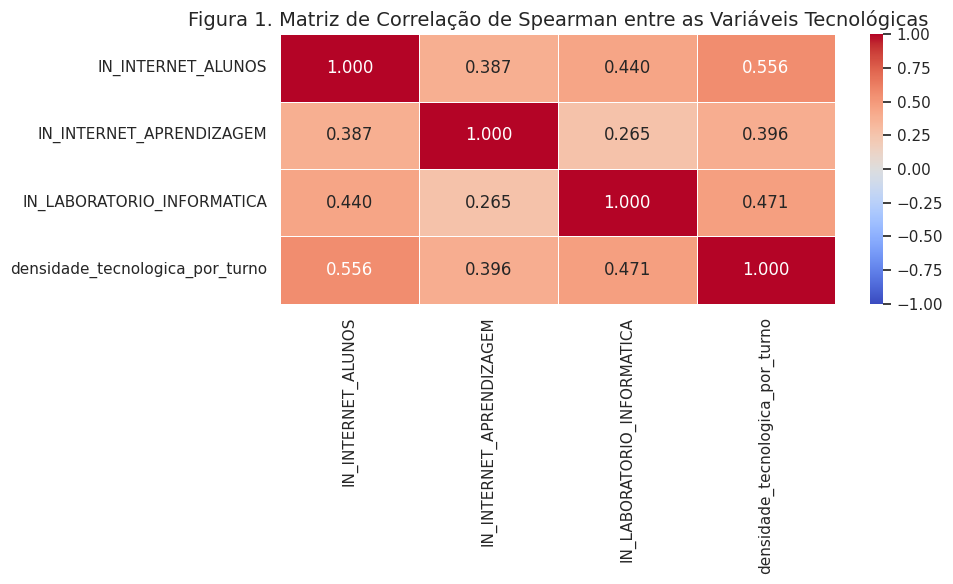

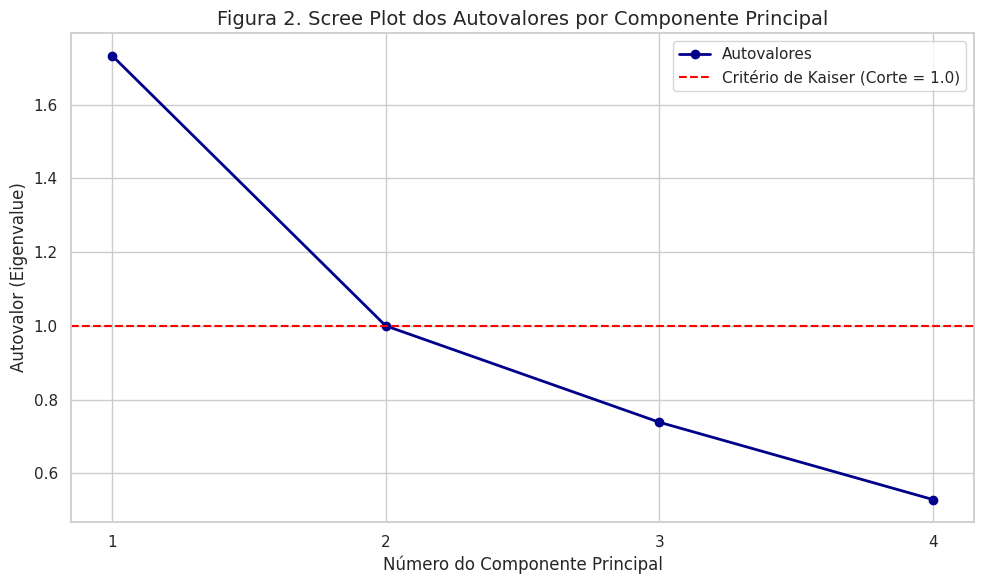

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração global de estilo para os gráficos do TCC (ABNT/Limpo)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# ==============================================================================
# FIGURA 1: MATRIZ DE CORRELAÇÃO DE SPEARMAN (PILARES DO SMED)
# ==============================================================================
plt.figure()
matriz_corr = df_modelagem[features_pca].corr(method='spearman')

# Plotando o Heatmap
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Figura 1. Matriz de Correlação de Spearman entre as Variáveis Tecnológicas")
plt.tight_layout()
plt.savefig("figura_1_matriz_correlação.png", dpi=300) # Salva em alta resolução na pasta
plt.show()

# ==============================================================================
# FIGURA 2: SCREE PLOT DO PCA (JUSTIFICATIVA DE RETENÇÃO) - CORRIGIDO
# ==============================================================================
plt.figure()
componentes_num = np.arange(1, len(autovalores) + 1)

# Gráfico de linha dos Autovalores (Ajustado de o_marker para marker)
plt.plot(componentes_num, autovalores, marker='o', linewidth=2, color='darkblue', label='Autovalores')

# Linha de corte do Critério de Kaiser (Autovalor = 1.0)
plt.axhline(y=1.0, color='red', linestyle='--', label='Critério de Kaiser (Corte = 1.0)')

plt.title("Figura 2. Scree Plot dos Autovalores por Componente Principal")
plt.xlabel("Número do Componente Principal")
plt.ylabel("Autovalor (Eigenvalue)")
plt.xticks(componentes_num)
plt.legend()
plt.tight_layout()
plt.savefig("figura_2_scree_plot.png", dpi=300)
plt.show()
# ==============================================================================
# FIGURA 3: BOXPLOT DO SMED COMPARANDO REDE PÚBLICA VS. REDE PRIVADA - CORRIGIDO
# ==============================================================================
plt.figure()

# Customizando as labels para exibição visual
df_plot_boxplot = df_modelagem.copy()
df_plot_boxplot['Rede de Ensino'] = df_plot_boxplot['is_publica'].map({1: 'Rede Pública', 0: 'Rede Privada'})

# Criando o Boxplot (Ajustado com hue e legend para eliminar o FutureWarning)
sns.boxplot(
    x='Rede de Ensino', 
    y='SMED', 
    data=df_plot_boxplot, 
    hue='Rede de Ensino', 
    palette='Set2', 
    width=0.5, 
    legend=False
)

plt.title("Figura 3. Distribuição do Score de Exclusão Digital (SMED) por Rede de Ensino")
plt.xlabel("Segmentação Administrativa")
plt.ylabel("SMED (0 a 100 - Maior indica maior Exclusão)")
plt.tight_layout()
plt.savefig("figura_3_boxplot_redes.png", dpi=300)
plt.show()

In [ ]:
# ==============================================================================
# FIGURA 4: BOXPLOT REGIONALIZADO DO SMED POR REDE E REGIÃO
# ==============================================================================
plt.figure(figsize=(12, 7))

# Criamos uma cópia para o gráfico com nomes limpos
df_plot_regional = df_modelagem.copy()
df_plot_regional['Rede de Ensino'] = df_plot_regional['is_publica'].map({1: 'Rede Pública', 0: 'Rede Privada'})

# Ordenando as regiões para o gráfico ficar elegante (Norte/Nordeste primeiro)
ordem_regioes = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']

# Criando o Boxplot Composto
sns.boxplot(
    x='NO_REGIAO', 
    y='SMED', 
    hue='Rede de Ensino', 
    data=df_plot_regional, 
    order=ordem_regioes,
    palette='Set2', 
    width=0.6
)

plt.title("Figura 4. Distribuição do Score de Exclusão Digital (SMED) por Região e Rede de Ensino")
plt.xlabel("Região Geográfica")
plt.ylabel("SMED (0 a 100 - Maior indica maior Exclusão)")
plt.legend(title="Segmentação")
plt.tight_layout()

# Salva a imagem na tua pasta
plt.savefig("figura_4_boxplot_regional.png", dpi=300)
plt.show()

código smed 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# ==============================================================================
# 1. CARREGAMENTO DOS DADOS DIRETO DO SEU BANCO DBT (DUCKDB)
# ==============================================================================
DB_PATH = 'dbt_project/data/censo_escolar.duckdb'

if not os.path.exists(DB_PATH):
    print(f"❌ Arquivo não encontrado no caminho: {DB_PATH}")
else:
    con = duckdb.connect(DB_PATH, read_only=True)
    
    # Define o caminho de busca dos esquemas do dbt
    con.execute("SET search_path='main_refined,main_staging,main'")
    
    # Carrega a sua tabela refinada para o DataFrame
    df_refined_censo = con.execute("SELECT * FROM refined_censo_escolar").df()
    con.close()
    
    print(f"✅ Sucesso! {len(df_refined_censo)} linhas carregadas do dbt.")
    

# =========================
# 1. Seleção das variáveis
# =========================
variaveis_smed = [
    "internet_aprendizagem",
    "internet_alunos",
    "densidade_tecnologica_turno",
    "laboratorio_informatica",
    "acesso_internet_computador",
    "proporcao_docentes_especialista_tic",
    "dependencia_adm"
]

smed = df_refined_censo[variaveis_smed].copy()

# =====================================
# 2. Recodificação para sentido do score
# =====================================
# Objetivo: maior valor final = maior exclusão digital

# Se os campos binários estiverem como texto ('Sim'/'Não'), recodifique:
mapa_binario = {
    "Sim": 1,
    "Não": 0,
    "SIM": 1,
    "NAO": 0,
    "NÃO": 0,
    True: 1,
    False: 0
}

for col in [
    "internet_aprendizagem",
    "internet_alunos",
    "laboratorio_informatica",
    "acesso_internet_computador"
]:
    if smed[col].dtype == 'object':
        smed[col] = smed[col].map(mapa_binario)

# dependencia_adm: pública = 1 (maior vulnerabilidade média), privada = 0
mapa_dependencia = {
    "Pública": 1,
    "Privada": 0,
    "Federal": 1,
    "Estadual": 1,
    "Municipal": 1
}
if smed["dependencia_adm"].dtype == 'object':
    smed["dependencia_adm"] = smed["dependencia_adm"].map(mapa_dependencia)

# Inverter variáveis em que maior valor significa MENOR exclusão
for col in [
    "internet_aprendizagem",
    "internet_alunos",
    "densidade_tecnologica_turno",
    "laboratorio_informatica",
    "acesso_internet_computador",
    "proporcao_docentes_especialista_tic"
]:
    smed[col] = smed[col] * -1

# =====================================
# 3. Tratamento de missing
# =====================================
# Estratégia simples: remover linhas incompletas para o PCA
smed_model = smed.dropna().copy()

# =====================================
# 4. Padronização Z-score
# =====================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(smed_model)

# =====================================
# 5. PCA
# =====================================
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Loadings da 1ª componente principal
loadings = pd.Series(
    pca.components_[0],
    index=smed_model.columns,
    name="loading_pc1"
)

# =====================================
# 6. Cálculo do SMED
# =====================================
# Score usando a primeira componente principal
smed_model["SMED"] = X_pca[:, 0]

# Se quiser garantir que maior valor = maior exclusão digital:
# compare com uma variável sabidamente associada à exclusão.
# Caso o sinal fique invertido, basta multiplicar por -1.

# Exemplo opcional:
# smed_model["SMED"] = smed_model["SMED"] * -1

# =====================================
# 7. Resultado final no DataFrame original
# =====================================
df_resultado = df.copy()
df_resultado.loc[smed_model.index, "SMED"] = smed_model["SMED"]

# =====================================
# 8. Insumos úteis para análise
# =====================================
variancia_explicada = pd.DataFrame({
    "componente": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "variancia_explicada": pca.explained_variance_ratio_,
    "variancia_acumulada": np.cumsum(pca.explained_variance_ratio_)
})

loadings_df = loadings.reset_index()
loadings_df.columns = ["variavel", "loading_pc1"]

print("Variáveis do SMED:")
print(variaveis_smed)
print("Loadings da 1ª componente:")
print(loadings.sort_values(ascending=False))
print("Variância explicada:")
print(variancia_explicada.head())
print("Resumo do SMED:")
print(smed_model["SMED"].describe())

PCA

/tmp/ipykernel_1184/412789595.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso', y='Variavel', data=loadings, palette='viridis')


                              Variavel      Peso
0                   IN_INTERNET_ALUNOS  0.703401
2  proporcao_docentes_especialista_tic  0.670183
1          densidade_tecnologica_total  0.236814


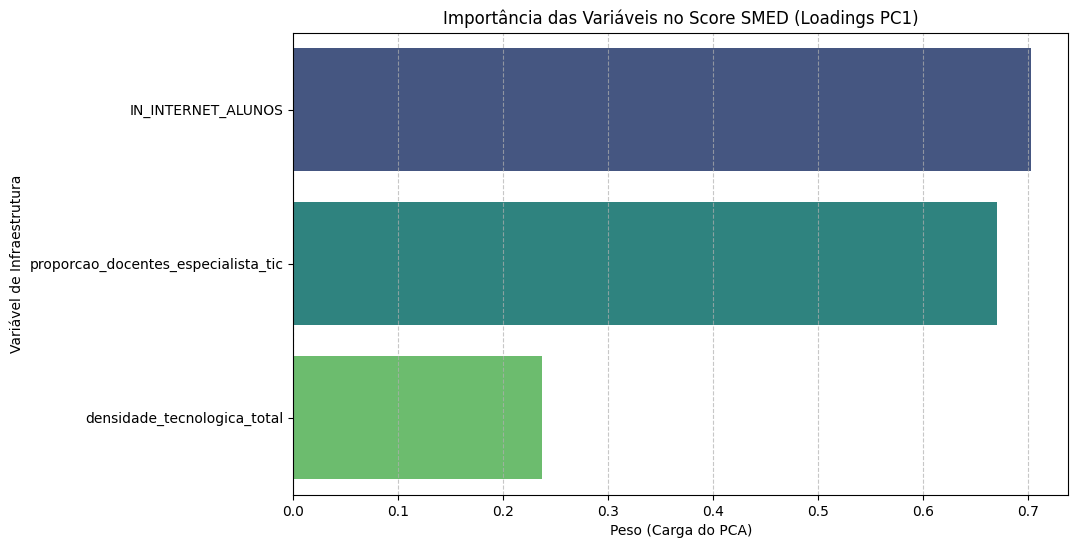

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definindo as variáveis baseadas no seu novo SQL
# Certifique-se de que estas colunas existem no seu DataFrame
features_smed = [
    'IN_INTERNET_ALUNOS', 'IN_INTERNET_APRENDIZAGEM', 'IN_LABORATORIO_INFORMATICA', 'densidade_tecnologica_turno','proporcao_docentes_especialista_tic'
    # Se você quiser adicionar as flags de laboratório e aprendizagem, 
    # elas precisam ser numéricas (0 ou 1)
]

# 2. Preparando os dados
x = df[features_smed].fillna(0)
x_scaled = StandardScaler().fit_transform(x)

# 3. PCA
pca = PCA(n_components=1)
pca.fit(x_scaled)

# 4. Extraindo as Cargas (Weights)
loadings = pd.DataFrame({
    'Variavel': features_smed,
    'Peso': pca.components_[0]
}).sort_values(by='Peso', ascending=False)

# 5. Gerando o Gráfico de Importância
plt.figure(figsize=(10, 6))
sns.barplot(x='Peso', y='Variavel', data=loadings, palette='viridis')
plt.title('Importância das Variáveis no Score SMED (Loadings PC1)')
plt.xlabel('Peso (Carga do PCA)')
plt.ylabel('Variável de Infraestrutura')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('pesos_smed.png')
print(loadings)

### Mapa de Coropletas (onde o município muda de cor)

In [14]:
import plotly.express as px

# Agrupando por município para o mapa não travar
df_mapa = df.groupby(['NO_MUNICIPIO', 'SG_UF', 'idhm']).agg({
    'SMED': 'mean',
    'pct_alunos_brasil_preta_parda': 'mean'
}).reset_index()

# Criando o gráfico de dispersão com "bolhas" (o tamanho da bolha é a exclusão)
fig = px.scatter(df_mapa, 
                 x="idhm", 
                 y="SMED", 
                 size="pct_alunos_brasil_preta_parda", 
                 color="SG_UF",
                 hover_name="NO_MUNICIPIO",
                 title="Relação IDHM vs Inclusão Digital (SMED) por Município")

fig.show()

ModuleNotFoundError: No module named 'plotly'

idhm 

In [15]:
# identificando os arquivos que estão na pasta dados_mapa
import os
print(os.listdir('data/dados_mapa'))

['IDHM.dbf', 'IDHM.shp', 'IDHM.xlsx', 'IDHM.qpj', 'IDHM.cpg', 'IDHM.shx', 'IDHM.xlsx:Zone.Identifier', 'IDHM.prj']


In [16]:
# arquivo shp é onde estão os dados do idhm

import geopandas as gpd
import os

# 1. Ajustado: A pasta 'dados_mapa' está dentro de 'data'
pasta_mapa = 'data/dados_mapa'

# 2. Encontra automaticamente o arquivo .shp lá dentro
arquivos = os.listdir(pasta_mapa)
nome_do_arquivo = [f for f in arquivos if f.endswith('.shp')][0]

# 3. Monta o caminho correto e carrega o mapa
caminho_final = os.path.join(pasta_mapa, nome_do_arquivo)
mapa = gpd.read_file(caminho_final)

print("✅ Mapa carregado com sucesso!")
print("\nColunas encontradas no mapa:")
print(mapa.columns.tolist())

# Mostra as primeiras linhas para checar os dados
display(mapa.head())

,Cod_ibge,Nome,Rotulo,Area_Km2,IDMH,IDHM_E,IDHM_L,IDHM_R,geometry
0,3500105,Adamantina,Adamantina,411.987,0.79,0.75,0.85,0.77,"POLYGON ((-51.17735 -21.69213, -51.17716 -21.6..."
1,3500204,Adolfo,Adolfo,211.055,0.73,0.64,0.84,0.71,"POLYGON ((-49.74715 -21.29637, -49.74682 -21.2..."
2,3500303,Aguai,Aguaí,474.554,0.71,0.60,0.85,0.70,"POLYGON ((-47.23298 -22.05409, -47.23289 -22.0..."
3,3500402,Aguas da Prata,Águas da Prata,142.961,0.78,0.71,0.88,0.75,"POLYGON ((-46.75758 -21.84763, -46.7575 -21.84..."
4,3500501,Aguas de Lindoia,Águas de Lindóia,60.126,0.74,0.67,0.84,0.72,"POLYGON ((-46.6602 -22.47948, -46.66018 -22.47..."


In [9]:
import geopandas as gpd

# Carregando o arquivo principal
mapa = gpd.read_file('data/dados_mapa/IDHM.shp')

# Verificando se o código do IBGE e o IDHM aparecem na tabela
print("Colunas do mapa:")
print(mapa.columns.tolist())

# Mostrando as primeiras linhas para confirmar os valores
# display(mapa[['NM_MUNICIP', 'CD_GEOCMU', 'IDHM2010', 'geometry']].head())

Colunas do mapa:
['Cod_ibge', 'Nome', 'Rotulo', 'Area_Km2', 'IDMH', 'IDHM_E', 'IDHM_L', 'IDHM_R', 'geometry']


In [13]:
import geopandas as gpd
import os

# 1. Nome da pasta que você criou dentro do projeto
pasta_mapa = 'data/dados_mapa'

# 2. Comando para o Python listar o que tem lá dentro e achar o arquivo do mapa
arquivos = os.listdir(pasta_mapa)
nome_do_arquivo = [f for f in arquivos if f.endswith('.shp')][0]

# 3. Agora sim, carregar o mapa
caminho_final = os.path.join(pasta_mapa, nome_do_arquivo)
mapa = gpd.read_file(caminho_final)

print("✅ Mapa carregado com sucesso!")
print(mapa.columns.tolist())
display(mapa.head())

✅ Mapa carregado com sucesso!
['Cod_ibge', 'Nome', 'Rotulo', 'Area_Km2', 'IDMH', 'IDHM_E', 'IDHM_L', 'IDHM_R', 'geometry']


,Cod_ibge,Nome,Rotulo,Area_Km2,IDMH,IDHM_E,IDHM_L,IDHM_R,geometry
0,3500105,Adamantina,Adamantina,411.987,0.79,0.75,0.85,0.77,"POLYGON ((-51.17735 -21.69213, -51.17716 -21.6..."
1,3500204,Adolfo,Adolfo,211.055,0.73,0.64,0.84,0.71,"POLYGON ((-49.74715 -21.29637, -49.74682 -21.2..."
2,3500303,Aguai,Aguaí,474.554,0.71,0.60,0.85,0.70,"POLYGON ((-47.23298 -22.05409, -47.23289 -22.0..."
3,3500402,Aguas da Prata,Águas da Prata,142.961,0.78,0.71,0.88,0.75,"POLYGON ((-46.75758 -21.84763, -46.7575 -21.84..."
4,3500501,Aguas de Lindoia,Águas de Lindóia,60.126,0.74,0.67,0.84,0.72,"POLYGON ((-46.6602 -22.47948, -46.66018 -22.47..."
